In [1]:
from sklearn.datasets import load_digits
digits = load_digits()

print(digits.data.shape)
print(digits.target.shape) 

(1797, 64)
(1797,)


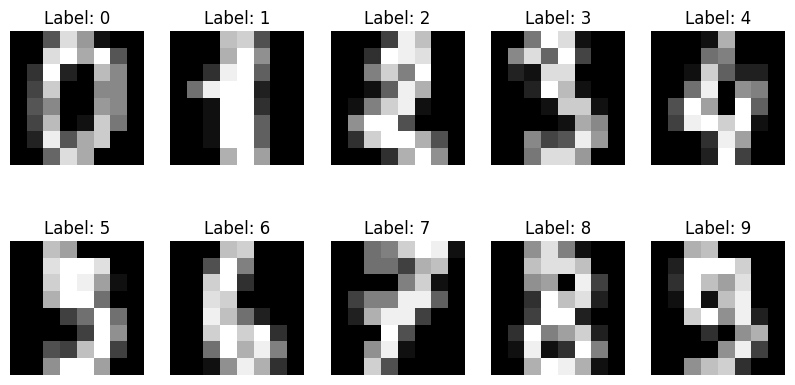

In [2]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {digits.target[i]}")
    ax.axis('off') 
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', max_iter=300, random_state=42)

mlp.fit(X_train_scaled, y_train)

y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy: 0.9833


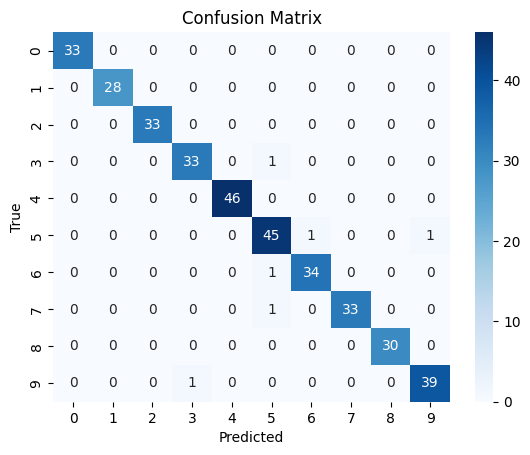

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.94      0.96      0.95        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.98       360
   macro avg       0.99      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_test_pred))

In [6]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (128,),(64,128,64)],
    'activation': ['relu', 'tanh', 'logistic']
}
grid_search = GridSearchCV(MLPClassifier(max_iter=300, random_state=42), param_grid, verbose=True, cv=5, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
best_mlp = grid_search.best_estimator_
y_test_pred_best = best_mlp.predict(X_test_scaled)
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)
print(f"Testing Accuracy with Best Parameters: {test_accuracy_best:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (64,)}
Best Cross-Validation Score: 0.9763
Testing Accuracy with Best Parameters: 0.9833
